In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn scipy networkx

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from scipy.fft import fft

import networkx as nx

# Mechanical System Digital Twin Visualization

This project simulates a digital twin of a mechanical system using sensor data.
The system analyzes machine behaviour through multiple analytical visualizations.

Sensors simulated:
• Pressure
• Flow
• Temperature
• Vibration
• RPM

Techniques used:
• Signal processing (FFT)
• Machine learning (Isolation Forest)
• Dimensionality reduction (PCA)
• Network analysis

# **1 Sensor Data Simulation**

In [ ]:
time = np.arange(0,1000)

rpm = 1500 + 50*np.sin(0.03*time)

pressure = 50 + 0.02*rpm + np.random.normal(0,2,1000)

flow = 0.6*pressure + np.random.normal(0,1,1000)

temperature = 60 + 0.01*rpm + np.random.normal(0,1,1000)

vibration = 0.002*rpm + 0.5*np.sin(0.5*time) + np.random.normal(0,0.2,1000)

df = pd.DataFrame({
"time":time,
"pressure":pressure,
"temperature":temperature,
"flow":flow,
"vibration":vibration,
"rpm":rpm
})

df.head()

,time,pressure,temperature,flow,vibration,rpm
0,0,76.624606,74.153599,44.557323,3.036487,1500.000000
1,1,79.347100,75.181122,48.184719,3.528911,1501.499775
2,2,77.676033,75.067427,48.991473,3.387467,1502.998200
3,3,83.921476,73.769392,50.954109,3.574672,1504.493927
4,4,81.854263,75.730093,48.930557,3.640198,1505.985610


# 2 Sensor Time Series Analysis

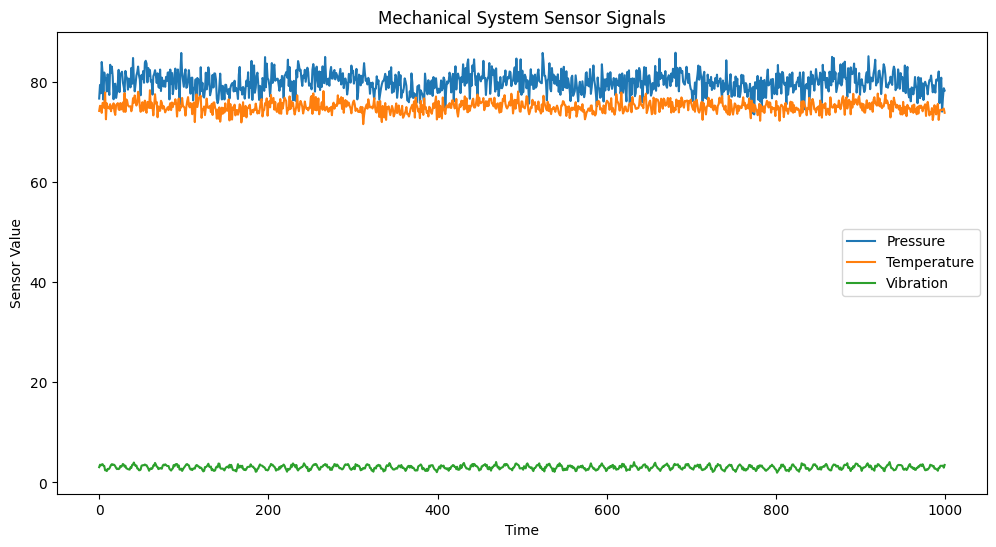

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df["time"], df["pressure"], label="Pressure")
plt.plot(df["time"], df["temperature"], label="Temperature")
plt.plot(df["time"], df["vibration"], label="Vibration")

plt.legend()
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.title("Mechanical System Sensor Signals")

plt.show()

# 3 Correlation **Analysis**

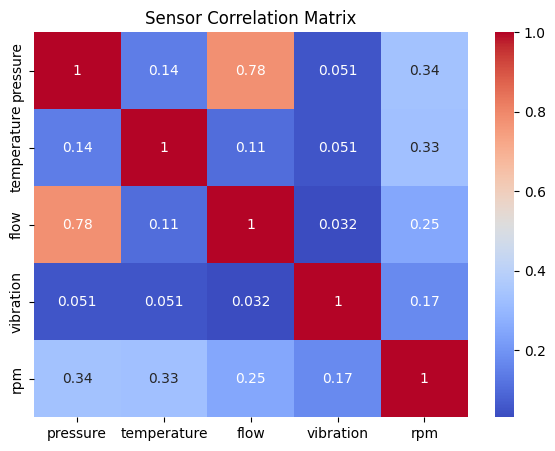

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(df.drop(columns=["time"]).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Sensor Correlation Matrix")

plt.show()

# 4 Frequency Analysis (FFT)

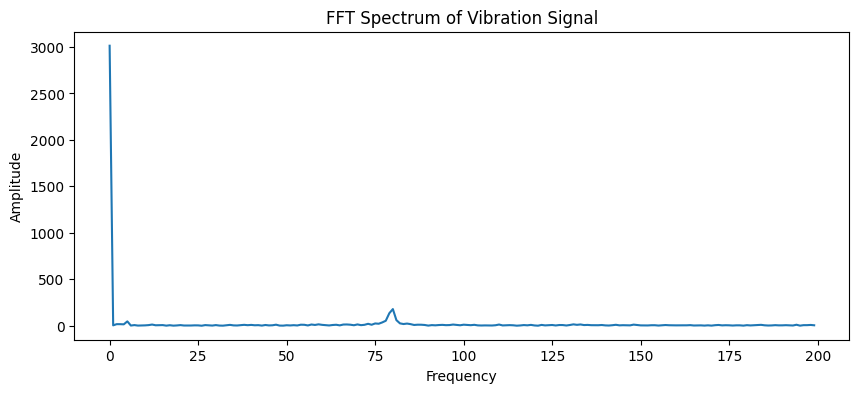

In [ ]:
signal = df["vibration"]

fft_values = np.abs(fft(signal))

plt.figure(figsize=(10,4))
plt.plot(fft_values[:200])

plt.title("FFT Spectrum of Vibration Signal")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

plt.show()

# 5 PCA Machine Health **Space**

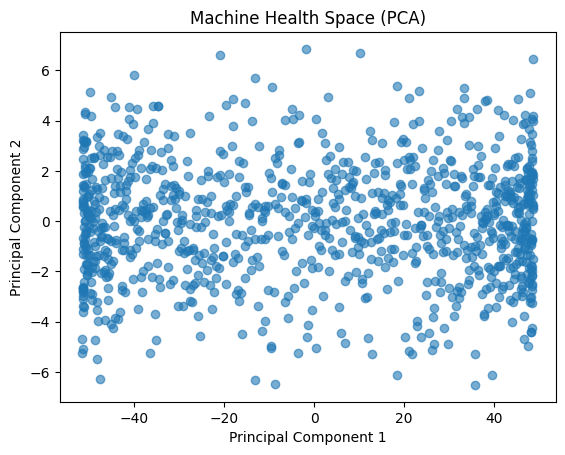

In [ ]:
features = df.drop(columns=["time","anomaly"], errors="ignore")

pca = PCA(n_components=2)

components = pca.fit_transform(features)

plt.scatter(components[:,0], components[:,1], alpha=0.6)

plt.title("Machine Health Space (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# 6 Anomaly Detection

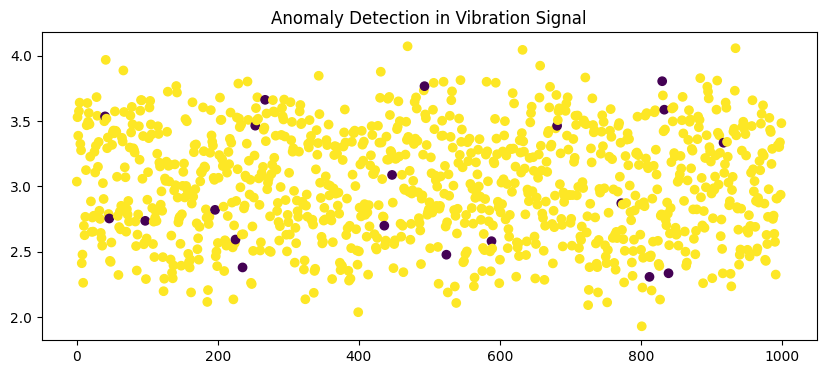

In [ ]:
model = IsolationForest(contamination=0.02)

df["anomaly"] = model.fit_predict(features)

plt.figure(figsize=(10,4))

plt.scatter(df["time"],
            df["vibration"],
            c=df["anomaly"])

plt.title("Anomaly Detection in Vibration Signal")

plt.show()

#  #7 Sensor Interaction Network

*   This graph represents relationships between machine sensors based on correlation.
Edges indicate strong interactions between system variables.


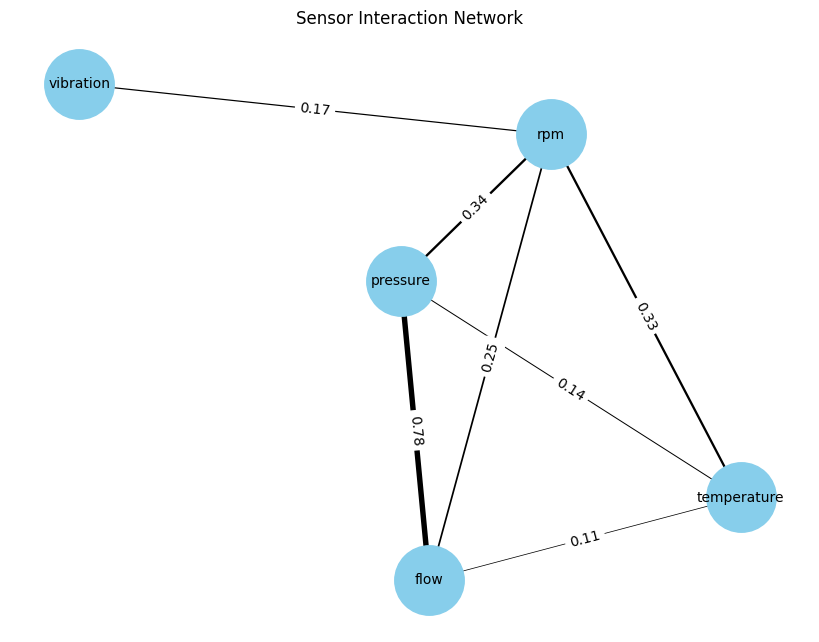

In [61]:
# 7 Sensor Interaction Network

import networkx as nx

# compute correlation matrix
corr = df.drop(columns=["time","anomaly"], errors="ignore").corr()

# create graph
G = nx.Graph()

# add nodes (sensors)
for sensor in corr.columns:
    G.add_node(sensor)

# add edges using correlation threshold
threshold = 0.1

for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i, j]) > threshold:
            G.add_edge(i, j, weight=corr.loc[i, j])

# graph layout
pos = nx.spring_layout(G, seed=42, k=1.2)

# edge thickness proportional to correlation strength
edges = G.edges()
weights = [abs(G[u][v]['weight']) * 5 for u, v in edges]

# edge labels
edge_labels = {(u, v): round(G[u][v]['weight'], 2) for u, v in edges}

# draw graph
plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="skyblue",
    font_size=10,
    width=weights
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Sensor Interaction Network")
plt.show()

# 8 Mechanical System Digital Twin Architecture

This diagram represents the physical structure of the mechanical system
being monitored by the digital twin.

Components:
Motor → Pump → Valve → Hydraulic Line → Actuator

Sensors monitor pressure, flow, vibration, temperature and RPM.

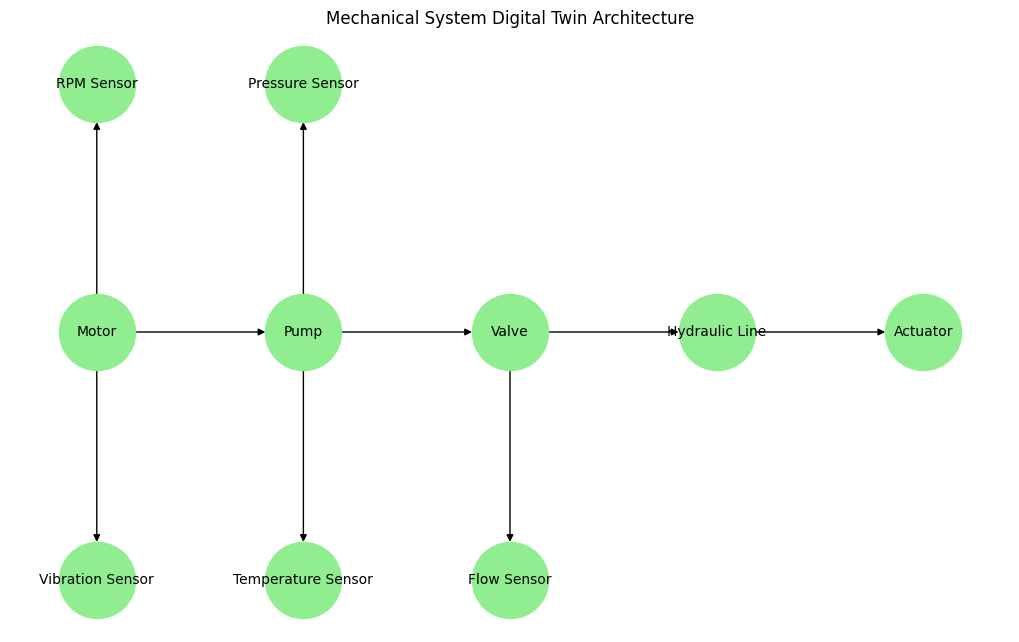

In [64]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G_sys = nx.DiGraph()

# Mechanical components
components = [
    "Motor",
    "Pump",
    "Valve",
    "Hydraulic Line",
    "Actuator"
]

# Sensors
sensors = [
    "RPM Sensor",
    "Pressure Sensor",
    "Flow Sensor",
    "Temperature Sensor",
    "Vibration Sensor"
]

# Add nodes
G_sys.add_nodes_from(components)
G_sys.add_nodes_from(sensors)

# Mechanical system flow
G_sys.add_edges_from([
    ("Motor", "Pump"),
    ("Pump", "Valve"),
    ("Valve", "Hydraulic Line"),
    ("Hydraulic Line", "Actuator")
])

# Sensor connections (where sensors measure the system)
G_sys.add_edges_from([
    ("Motor", "RPM Sensor"),
    ("Motor", "Vibration Sensor"),
    ("Pump", "Pressure Sensor"),
    ("Pump", "Temperature Sensor"),
    ("Valve", "Flow Sensor")
])

# Define a structured layout for clarity
pos = {
    "Motor": (0,0),
    "Pump": (2,0),
    "Valve": (4,0),
    "Hydraulic Line": (6,0),
    "Actuator": (8,0),

    "RPM Sensor": (0,2),
    "Vibration Sensor": (0,-2),

    "Pressure Sensor": (2,2),
    "Temperature Sensor": (2,-2),

    "Flow Sensor": (4,-2)
}

# Draw graph
plt.figure(figsize=(10,6))

nx.draw(
    G_sys,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightgreen",
    font_size=10,
    arrows=True
)

plt.title("Mechanical System Digital Twin Architecture")

plt.show()